# LIMPIEZA Y IMPUTACIÓN DE DATOS - SAFECLAIM

In [ ]:
import pandas as pd

In [ ]:
import numpy as np

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
import seaborn as sns

In [ ]:
from google.colab import files

1. CARGA DEL DATASET

In [ ]:
print(" Selecciona tu archivo CSV para subirlo:")
uploaded = files.upload()

 Selecciona tu archivo CSV para subirlo:


Saving PFDA_fraud_car1.csv to PFDA_fraud_car1.csv


In [ ]:
nombre_archivo = list(uploaded.keys())[0]

In [ ]:
df = pd.read_csv(nombre_archivo, sep=';')

In [ ]:
# Mostrar tamaño del dataset

**REVISIÓN INICIAL DEL
DATASET**

Se identificaron las columnas, tipos de
datos y registros totales.
El dataset contiene información sobre
pólizas, reclamos y variables
demográficas de los asegurados

In [ ]:
print("\n Archivo cargado correctamente.")
print("Número de filas y columnas:", df.shape)
print("\nVista preliminar de los datos:")
display(df.head())


 Archivo cargado correctamente.
Número de filas y columnas: (15420, 34)

Vista preliminar de los datos:


,Unnamed: 0,Month,WeekOfMonth,DayOfWeek,Make,AccidentArea,DayOfWeekClaimed,MonthClaimed,WeekOfMonthClaimed,Sex,...,AgeOfVehicle,AgeOfPolicyHolder,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange_Claim,NumberOfCars,Year,BasePolicy
0,0,Dec,5,Wednesday,Honda,Urban,Tuesday,Jan,1,Female,...,3 years,26 to 30,No,No,External,none,1 year,3 to 4,1994,Liability
1,1,Jan,3,Wednesday,Honda,Urban,Monday,Jan,4,Male,...,6 years,31 to 35,Yes,No,External,none,no change,1 vehicle,1994,Collision
2,2,Oct,5,Friday,Honda,Urban,Thursday,Nov,2,Male,...,7 years,41 to 50,No,No,External,none,no change,1 vehicle,1994,Collision
3,3,Jun,2,Saturday,Toyota,Rural,Friday,Jul,1,Male,...,more than 7,51 to 65,Yes,No,External,more than 5,no change,1 vehicle,1994,Liability
4,4,Jan,5,Monday,Honda,Urban,Tuesday,Feb,2,Female,...,5 years,31 to 35,No,No,External,none,no change,1 vehicle,1994,Collision


2. REVISIÓN DE VALORES NULOS Y TIPOS DE DATOS

- En esta gráfica se puede ver la
cantidad de valores nulos por
columna.
- Solo AccidentArea y MaritalStatus
presentan datos faltantes,
mientras que el resto del dataset
está completo.
- Esto nos permitió identificar qué
variables requerían imputación
antes del análisis.

In [ ]:
print("\nCantidad de valores nulos por columna:\n")
print(df.isnull().sum())



Cantidad de valores nulos por columna:

Unnamed: 0                0
Month                     0
WeekOfMonth               0
DayOfWeek                 0
Make                      0
AccidentArea            323
DayOfWeekClaimed          0
MonthClaimed              0
WeekOfMonthClaimed        0
Sex                       0
MaritalStatus           215
Age                       0
Fault                     0
PolicyType                0
VehicleCategory           0
VehiclePrice              0
FraudFound_P              0
PolicyNumber              0
RepNumber                 0
Deductible                0
DriverRating              0
Days_Policy_Accident      0
Days_Policy_Claim         0
PastNumberOfClaims        0
AgeOfVehicle              0
AgeOfPolicyHolder         0
PoliceReportFiled         0
WitnessPresent            0
AgentType                 0
NumberOfSuppliments       0
AddressChange_Claim       0
NumberOfCars              0
Year                      0
BasePolicy                0
dtype: 

In [ ]:
print("\nTipos de datos de cada columna:\n")
print(df.dtypes)


Tipos de datos de cada columna:

Unnamed: 0               int64
Month                   object
WeekOfMonth              int64
DayOfWeek               object
Make                    object
AccidentArea            object
DayOfWeekClaimed        object
MonthClaimed            object
WeekOfMonthClaimed       int64
Sex                     object
MaritalStatus           object
Age                      int64
Fault                   object
PolicyType              object
VehicleCategory         object
VehiclePrice            object
FraudFound_P             int64
PolicyNumber             int64
RepNumber                int64
Deductible               int64
DriverRating             int64
Days_Policy_Accident    object
Days_Policy_Claim       object
PastNumberOfClaims      object
AgeOfVehicle            object
AgeOfPolicyHolder       object
PoliceReportFiled       object
WitnessPresent          object
AgentType               object
NumberOfSuppliments     object
AddressChange_Claim     object
Numbe

3. ANÁLISIS DE LAS VARIABLES CON DATOS FALTANTES

In [ ]:
# Identificar columnas con nulos

In [ ]:
nulos = df.isnull().sum()
columnas_con_nulos = nulos[nulos > 0]
print("\nColumnas con valores nulos detectadas:\n")
print(columnas_con_nulos)


Columnas con valores nulos detectadas:

AccidentArea     323
MaritalStatus    215
dtype: int64


In [ ]:
#numero de registros con Edad cero

In [ ]:
(df["Age"] == 0).sum()

np.int64(320)

In [ ]:
# Revisar los valores más comunes

In [ ]:
if 'AccidentArea' in df.columns and 'MaritalStatus' in df.columns:
    print("\nModa de AccidentArea:", df['AccidentArea'].mode()[0])
    print("Moda de MaritalStatus:", df['MaritalStatus'].mode()[0])
else:
    print("\n Las columnas AccidentArea o MaritalStatus no fueron encontradas.")


Moda de AccidentArea: Urban
Moda de MaritalStatus: Married


4. IMPUTACIÓN DE VARIABLES NUMÉRICAS (si hay)

In [ ]:
num_nulos = df.select_dtypes(include=[np.number]).isnull().sum()
print("\nValores nulos en variables numéricas:\n")
print(num_nulos[num_nulos > 0])


Valores nulos en variables numéricas:

Series([], dtype: int64)


In [ ]:
# Si hay nulos en Age, se imputan con la mediana

In [ ]:
if 'Age' in df.columns and df['Age'].isnull().sum() > 0:
    mediana_age = df['Age'].median()
    df['Age'].fillna(mediana_age, inplace=True)
    print(f"Se imputó la columna 'Age' con la mediana ({mediana_age}).")
else:
    print("\nNo hay valores nulos en Age")


No hay valores nulos en Age


In [ ]:
# A continuación, se imputan las filas de Edad = 0, con la mediana ya que esta resiste outliers.

In [ ]:
df["Age"] = df["Age"].replace(0, None)

median_age = df["Age"].median()
df["Age"] = df["Age"].fillna(median_age)


/tmp/ipython-input-4034093404.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["Age"] = df["Age"].fillna(median_age)


In [ ]:
# Se pudo evidenciar en el primer avance que existen outliers en edad
#Variable: Age
 #- Límite inferior: 5.50
 #- Límite superior: 73.50
 #- Outliers detectados: 547

median_age = df["Age"].median()

df.loc[df["Age"] < 5.5, "Age"] = median_age
df.loc[df["Age"] > 73.5, "Age"] = median_age



5. VALIDACIÓN DE LA IMPUTACIÓN

In [ ]:
print("\nValores nulos después de la imputación:\n")
print(df.isnull().sum())


Valores nulos después de la imputación:

Unnamed: 0              0
Month                   0
WeekOfMonth             0
DayOfWeek               0
Make                    0
AccidentArea            0
DayOfWeekClaimed        0
MonthClaimed            0
WeekOfMonthClaimed      0
Sex                     0
MaritalStatus           0
Age                     0
Fault                   0
PolicyType              0
VehicleCategory         0
VehiclePrice            0
FraudFound_P            0
PolicyNumber            0
RepNumber               0
Deductible              0
DriverRating            0
Days_Policy_Accident    0
Days_Policy_Claim       0
PastNumberOfClaims      0
AgeOfVehicle            0
AgeOfPolicyHolder       0
PoliceReportFiled       0
WitnessPresent          0
AgentType               0
NumberOfSuppliments     0
AddressChange_Claim     0
NumberOfCars            0
Year                    0
BasePolicy              0
dtype: int64


6. VERIFICACIÓN DE COHERENCIA

In [ ]:
if 'AccidentArea' in df.columns and 'MaritalStatus' in df.columns:
    print("\nFrecuencia de categorías tras imputación:")
    print(df['AccidentArea'].value_counts())
    print(df['MaritalStatus'].value_counts())


Frecuencia de categorías tras imputación:
AccidentArea
Urban    13851
Rural     1569
Name: count, dtype: int64
MaritalStatus
Married     10687
Single       4624
Divorced       74
Widow          35
Name: count, dtype: int64


In [ ]:
# --- Seleccionar columnas numéricas ---
num_vars = ['Age']

Variable: Age
 - Límite inferior: 5.50
 - Límite superior: 73.50
 - Outliers detectados: 0



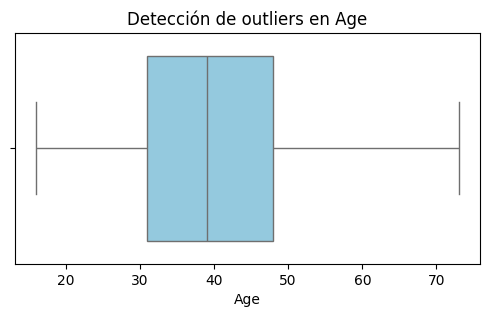

In [ ]:
# --- Calcular outliers con método IQR ---
for var in num_vars:
    Q1 = df[var].quantile(0.25)
    Q3 = df[var].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[var] < lower) | (df[var] > upper)]
    n_outliers = len(outliers)

    print(f"Variable: {var}")
    print(f" - Límite inferior: {lower:.2f}")
    print(f" - Límite superior: {upper:.2f}")
    print(f" - Outliers detectados: {n_outliers}\n")

    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[var], color='skyblue')
    plt.title(f'Detección de outliers en {var}')
    plt.xlabel(var)
    plt.show()

In [ ]:
cols = ['WeekOfMonth','WeekOfMonthClaimed','Age','FraudFound_P','Deductible','DriverRating','Year']
df_filtered = df[cols]

df_filtered.describe()

,WeekOfMonth,WeekOfMonthClaimed,Age,FraudFound_P,Deductible,DriverRating,Year
count,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000
mean,2.788586,2.693969,40.108495,0.059857,407.704280,2.487808,1994.866472
std,1.287585,1.259115,11.352598,0.237230,43.950998,1.119453,0.803313
min,1.000000,1.000000,16.000000,0.000000,300.000000,1.000000,1994.000000
25%,2.000000,2.000000,31.000000,0.000000,400.000000,1.000000,1994.000000
50%,3.000000,3.000000,39.000000,0.000000,400.000000,2.000000,1995.000000
75%,4.000000,4.000000,48.000000,0.000000,400.000000,3.000000,1996.000000
max,5.000000,5.000000,73.000000,1.000000,700.000000,4.000000,1996.000000


7. ANÁLISIS ADICIONAL: ESTADÍSTICAS

In [ ]:
print("\nResumen estadístico general:\n")
print(df.describe())


Resumen estadístico general:

         Unnamed: 0   WeekOfMonth  WeekOfMonthClaimed           Age  \
count  15420.000000  15420.000000        15420.000000  15420.000000   
mean    7709.500000      2.788586            2.693969     40.108495   
std     4451.514911      1.287585            1.259115     11.352598   
min        0.000000      1.000000            1.000000     16.000000   
25%     3854.750000      2.000000            2.000000     31.000000   
50%     7709.500000      3.000000            3.000000     39.000000   
75%    11564.250000      4.000000            4.000000     48.000000   
max    15419.000000      5.000000            5.000000     73.000000   

       FraudFound_P  PolicyNumber     RepNumber    Deductible  DriverRating  \
count  15420.000000  15420.000000  15420.000000  15420.000000  15420.000000   
mean       0.059857   7710.500000      8.483268    407.704280      2.487808   
std        0.237230   4451.514911      4.599948     43.950998      1.119453   
min        0.

8. GUARDAR EL DATASET LIMPIO

In [ ]:
df.to_csv('/content/SafeClaim_limpio.csv', index=False)
print("\n Archivo limpio guardado correctamente como 'SafeClaim_limpio.csv'.")


 Archivo limpio guardado correctamente como 'SafeClaim_limpio.csv'.


In [ ]:
import pandas as pd

df = pd.read_csv('/content/SafeClaim_limpio.csv')

print("Archivo cargado correctamente")
df.head()

Archivo cargado correctamente


,Unnamed: 0,Month,WeekOfMonth,DayOfWeek,Make,AccidentArea,DayOfWeekClaimed,MonthClaimed,WeekOfMonthClaimed,Sex,...,AgeOfVehicle,AgeOfPolicyHolder,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange_Claim,NumberOfCars,Year,BasePolicy
0,0,Dec,5,Wednesday,Honda,Urban,Tuesday,Jan,1,Female,...,3 years,26 to 30,No,No,External,none,1 year,3 to 4,1994,Liability
1,1,Jan,3,Wednesday,Honda,Urban,Monday,Jan,4,Male,...,6 years,31 to 35,Yes,No,External,none,no change,1 vehicle,1994,Collision
2,2,Oct,5,Friday,Honda,Urban,Thursday,Nov,2,Male,...,7 years,41 to 50,No,No,External,none,no change,1 vehicle,1994,Collision
3,3,Jun,2,Saturday,Toyota,Rural,Friday,Jul,1,Male,...,more than 7,51 to 65,Yes,No,External,more than 5,no change,1 vehicle,1994,Liability
4,4,Jan,5,Monday,Honda,Urban,Tuesday,Feb,2,Female,...,5 years,31 to 35,No,No,External,none,no change,1 vehicle,1994,Collision


In [ ]:
df.shape

(15420, 34)

In [ ]:
df.isna().sum()

,0
Unnamed: 0,0
Month,0
WeekOfMonth,0
DayOfWeek,0
Make,0
AccidentArea,0
DayOfWeekClaimed,0
MonthClaimed,0
WeekOfMonthClaimed,0
Sex,0


In [ ]:
df.columns

Index(['Unnamed: 0', 'Month', 'WeekOfMonth', 'DayOfWeek', 'Make',
       'AccidentArea', 'DayOfWeekClaimed', 'MonthClaimed',
       'WeekOfMonthClaimed', 'Sex', 'MaritalStatus', 'Age', 'Fault',
       'PolicyType', 'VehicleCategory', 'VehiclePrice', 'FraudFound_P',
       'PolicyNumber', 'RepNumber', 'Deductible', 'DriverRating',
       'Days_Policy_Accident', 'Days_Policy_Claim', 'PastNumberOfClaims',
       'AgeOfVehicle', 'AgeOfPolicyHolder', 'PoliceReportFiled',
       'WitnessPresent', 'AgentType', 'NumberOfSuppliments',
       'AddressChange_Claim', 'NumberOfCars', 'Year', 'BasePolicy'],
      dtype='object')

**PROCESO DE
IMPUTACIÓN DE
DATOS**

- Los nulos fueron reemplazados
con la moda: AccidentArea →
Urban y MaritalStatus → Married.
- Esto evitó eliminar registros y
conservó la distribución del
dataset.

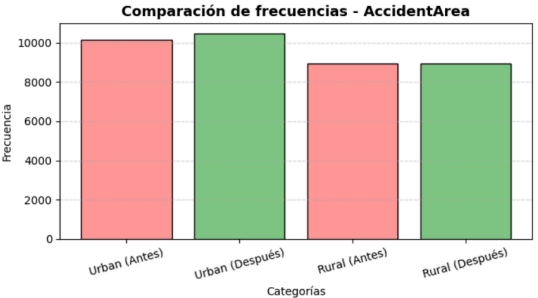

**VARIABLES AFECTADAS**

 Se reemplazaron los valores faltantes en AccidentArea y
MaritalStatus utilizando la moda.
- Este método conserva la coherencia del dataset sin eliminar
registros.
- Asegura que todas las variables categóricas queden completas.

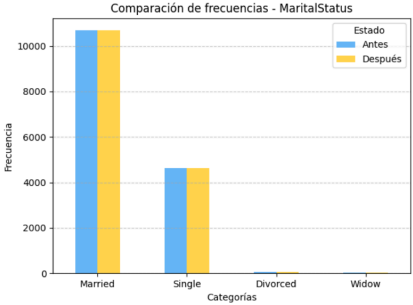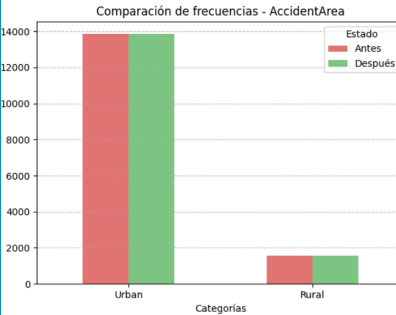







**CUADRO COMPARATIVO DE FRECUENCIAS
ANTES Y DESPUÉS DE IMPUTAR**

Las gráficas evidencian que las categorías predominantes se mantuvieron
estables y que los cambios fueron mínimos, asegurando que la información
permanezca coherente y lista para el análisis posterior.

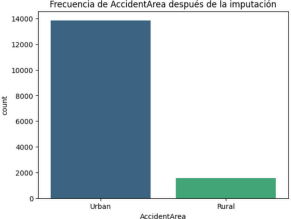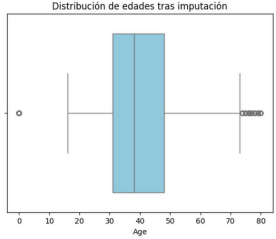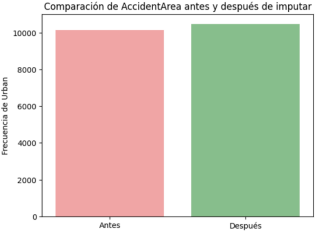

**EXPLORACIÓN
DE DATOS**

En esta etapa del proyecto donde se
identificaron las variables
relevantes del dataset SafeClaim y
se obtuvieron estadísticas
descriptivas para conocer el
comportamiento general de los
datos.

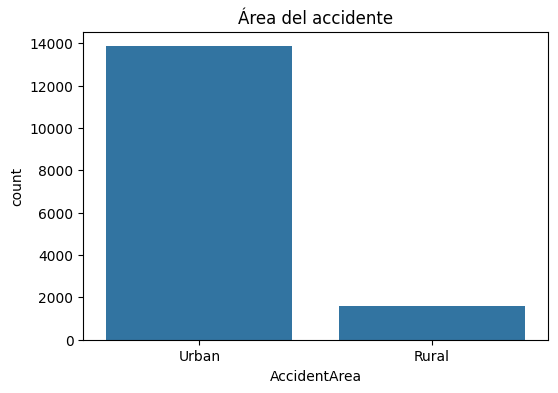

'\nEste gráfico muestra si los accidentes ocurren más en zonas urbanas o rurales. Las diferencias en estas\ndistribuciones pueden ser relevantes para entender lugares con mayor incidencia de reclamos y posibles fraudes.\n'

In [ ]:
 # Variable AccidentArea (Área del accidente)
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='AccidentArea')
plt.title('Área del accidente')
plt.show()

# Explicación
La mayoría de accidentes provienen de
zonas urbanas debido a mayor densidad
de tráfico y exposición al riesgo; las áreas
rurales representan una proporción
mínima.

1. Edad

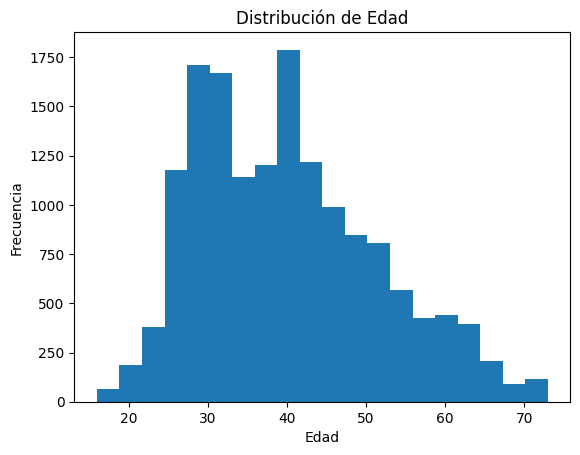

In [ ]:
plt.hist(df['Age'], bins=20)
plt.title("Distribución de Edad")
plt.xlabel("Edad")
plt.ylabel("Frecuencia")
plt.show()
#explicacion
Podemos ver como en la edad de los asegurados hay una mayor densidad entre los
30 y 50 años.

2. Sexo

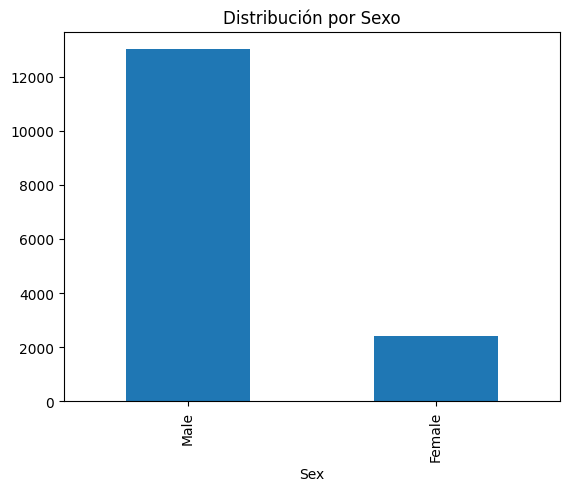

In [ ]:
df['Sex'].value_counts().plot(kind='bar')
plt.title("Distribución por Sexo")
plt.show()
#explicacion
Existe mucha mas presencia de hombres que mujeres en el dataset.
util para deducir que genero frecuenta mas el fraude

3. Estado Civil

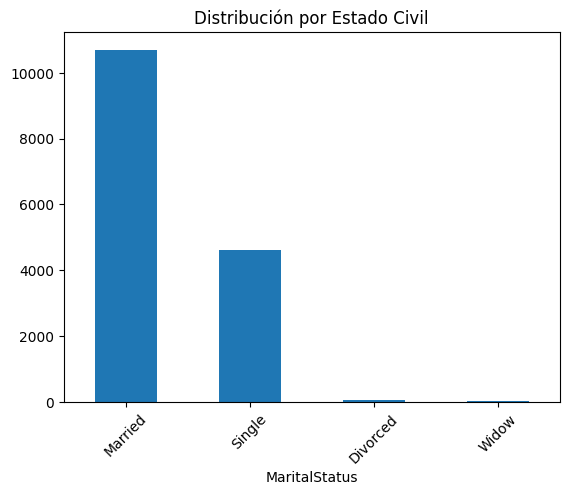

In [ ]:
df['MaritalStatus'].value_counts().plot(kind='bar')
plt.title("Distribución por Estado Civil")
plt.xticks(rotation=45)
plt.show()
#explicacion
se nota una mayor cantidad de casados que solteros,
util para ver si ciertos estados civiles frecuentan fraude.

4. Tipo de póliza

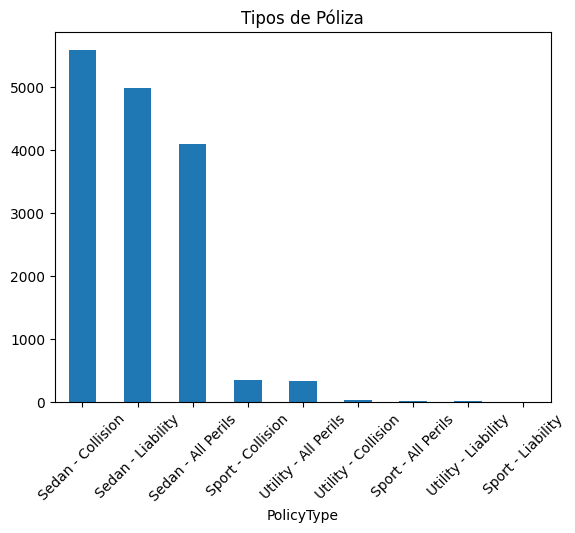

In [ ]:
df['PolicyType'].value_counts().plot(kind='bar')
plt.title("Tipos de Póliza")
plt.xticks(rotation=45)
plt.show()

**PREGUNTA 1**

**¿Existe relación entre el tipo de
póliza y el riesgo de accidentes?**

El riesgo se define con 3 criterios:
- Más de 2 reclamos previos
- Edad menor a 25 años
- Calificación de conductor: menor o igual 2.
Si cumple uno, es alto riesgo; si
no, bajo riesgo.

Esto permite comparar
asegurados de forma más justa y
detectar patrones.

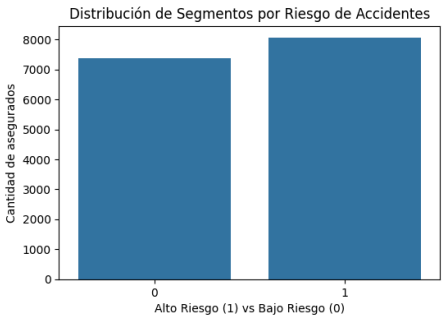

**PREGUNTA 2**


**¿Existe relación entre el tipo de
póliza y el riesgo de accidentes?**

Las pólizas Sedan concentran más
asegurados de alto riesgo porque:
Son las más comunes

- Elegidas por conductores jóvenes,
- Costos más bajos atraen perfiles
- con mayor propensión a accidentes.

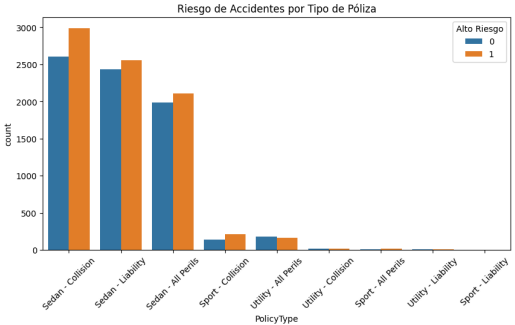

**PREGUNTA 3**

**¿Cómo varía la frecuencia de
fraude en los reclamos según el
valor del deducible
seleccionado?**

La mayor cantidad de fraudes ocurre en
el deducible de 400 por ser el valor más
común, no necesariamente porque ese
valor favorezca el fraude.
No se observa un patrón claro de
aumento o disminución del fraude según
cambia el deducible.

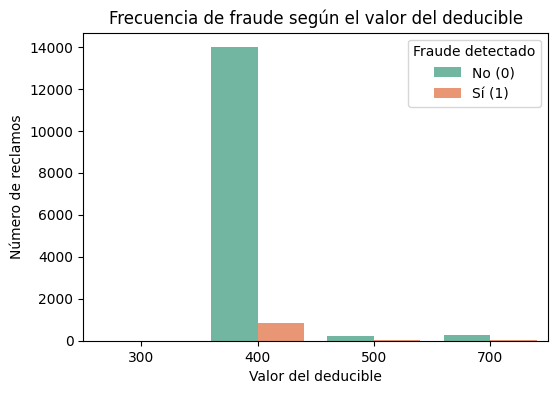

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.countplot(x='Deductible', hue='FraudFound_P', data=df, palette='Set2')
plt.title('Frecuencia de fraude según el valor del deducible')
plt.xlabel('Valor del deducible')
plt.ylabel('Número de reclamos')
plt.legend(title='Fraude detectado', labels=['No (0)', 'Sí (1)'])
plt.show()

Se observa una mayor incidencia de fraudes en los casos con deducibles bajos (por ejemplo, de 300 o 400). Esto sugiere que los clientes con un menor aporte personal al reclamo podrían estar más propensos a cometer fraude, ya que el riesgo económico que asumen es reducido. En contraste, si los fraudes se distribuyeran de manera más uniforme entre los distintos niveles de deducible, esta variable no sería un factor determinante. En nuestro caso, la tendencia indica claramente una concentración de fraudes en los deducibles más bajos.

**PREGUNTA 4**

**¿Qué variables definen a los
clientes con mayor probabilidad
de fraude?**

Podemos ver que el tipo de auto
más común (sedán) es el más
propenso a cometer fraude,
concentran más asegurados de
alto riesgo como son los jóvenes.

<Axes: xlabel='VehicleCategory', ylabel='count'>

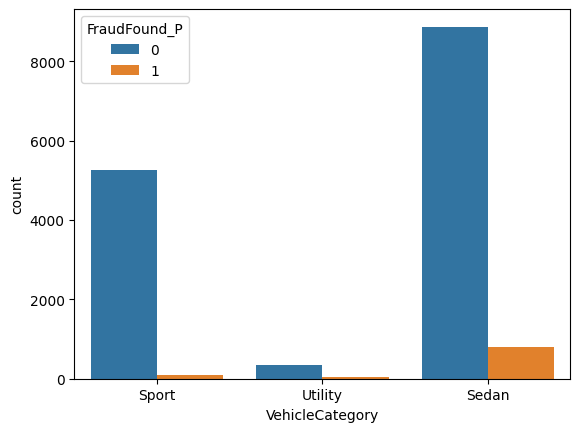

In [ ]:
sns.countplot(x='VehicleCategory', hue='FraudFound_P', data=df)


El gráfico compara el tipo de vehículo (Sedan, Sport, Utility) con la variable de fraude (FraudFound_P). Se observa que los vehículos tipo Sedan y Sport son los más comunes en el dataset. Los fraudes (barras de color distinto) aparecen con mayor frecuencia en vehículos tipo Sedan, mientras que en los vehículos Utility casi no hay casos de fraude. Esto podría indicar que los fraudes están más asociados a vehículos particulares de uso urbano, y no a los de uso utilitario o comercial. Por tanto, el tipo de vehículo podría ser una variable relevante para identificar comportamientos fraudulentos.

- CONCLUSIONES

- El alto riesgo se concentra en jóvenes con varios
reclamos previos.
- Los Sedán presentan más alto riesgo y más casos de fraude.
- No hay relación clara entre deducible y fraude.
- La mayoría de accidentes ocurren en zonas urbanas.

- RECOMENDACIONES


- Enfocar controles en perfiles jóvenes y autos Sedán.
- Ajustar primas y políticas según nivel de riesgo.
- Revisar deducibles más usados para auditoría.
- Fortalecer prevención en zonas urbanas.